# GFM maximum flood extent with STAC

This notebook demonstrates how to find GFM data using STAC, load it into an xarray object, and calculate a result.

As an example, we calculate the maximum flood extent over a time range and area of interest in Southern Mozambique. In January 2026, the area suffered from severe weather and floods.

## Prepare Python environment

In this notebook, we are using Python 3.11.10. First, let's install the necessary Python packages.

In [ ]:
!pip install pystac_client==0.9.0 odc-stac==0.5.2 rioxarray==0.19.0 matplotlib==3.10.8 --user

## First some imports

In [ ]:
import pyproj
import rioxarray # noqa
import xarray as xr
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.geometry import box
from pystac_client import Client
from odc import stac as odc_stac
from pathlib import Path

## Search and load data

We will define our area (AOI) and time range of interest for which we want
to calculate the maximum flood extent for. For defining a bounding box, you can
use [this web tool](http://bboxfinder.com).

All GFM data is registered as a [STAC](https://stacspec.org/en/) collection.
Please find more information about STAC in our [documentation](https://docs.eodc.eu/services/stac.html).

In [ ]:
use_case_name = "Southern_Mozambique_Jan_2026"

# Define bounding box (West, South, East, North) - Southern Mozambique
aoi = box(32.048307386, -25.272982457, 34.109853235, -23.221383919)

# Define time range
time_range = (datetime(2026, 1, 7), datetime(2026, 1, 28))

### Extract GFM Data

In [ ]:
# Define the output path, where you want to save temporary data and final results
output_path = Path("./gfm_maximum_flood_extent") / use_case_name
output_path.mkdir(parents=True, exist_ok=True)

# EODC STAC API URL
eodc_catalog = Client.open("https://stac.eodc.eu/api/v1")

# Define search query using pystac_client
search = eodc_catalog.search(
    max_items=1000,
    collections=["GFM"],
    bbox=aoi.bounds,
    datetime=time_range
)

# Get all items
items = search.item_collection()
if not items:
    raise RuntimeError("No items found — check your AOI, time range, or collection name.")

print(f"Found {len(items)} items matching filter criteria.")

# Retrieve the coordinate reference system (CRS) from one of the found items
crs_equi7 = pyproj.CRS.from_wkt(items[0].properties["proj:wkt2"])

### Lazy-load the returned data

We use `odc-stac` to load the STAC items into an `xarray.Dataset` in the Equi7Grid projection. The data is lazy-loaded — nothing is downloaded until a computation is triggered.

The asset we are interested in is `ensemble_flood_extent`. The required parameters — CRS and resolution — are read directly from the STAC item metadata.

In [ ]:
asset_names = ["ensemble_flood_extent"]

# Retrieve the resolution of the data
resolution = items[0].properties.get("gsd", 20)  # fallback to 20m if gsd missing

# By setting chunks, the odc library "lazy loads" the data. -1 for time means
# that all time steps are included in one chunk. Reduce the chunk size for x
# and/or y if your kernel crashes due to out of memory issues
raw_data = odc_stac.load(
    items,
    bbox=aoi.bounds,
    crs=crs_equi7,
    bands=asset_names,
    resolution=resolution,
    dtype='uint8',
    groupby="solar_day",
    chunks={"x": 4096, "y": 4096, "time": -1},
)

## Save data to a Zarr store (recommended)

Saving the downloaded data to disk as a Zarr store avoids re-downloading every time you run this notebook. The cell below checks whether a store already exists and loads it directly from disk if so — otherwise it triggers the download and writes the result to disk.

> **Note:** The first run will download the data, which may take a few minutes depending on your internet connection.

In [ ]:
zarr_store = output_path / "gfm_data.zarr"

if zarr_store.exists():
    raw_data = xr.open_zarr(zarr_store)
    print(f"Loaded existing Zarr store: {zarr_store}")
else:
    raw_data.to_zarr(zarr_store)
    print(f"Downloaded and saved data to: {zarr_store}")

## Process locally

Filter out nodata and no-flood pixels, then sum over time. Any pixel that was flooded at least once becomes 1 in the binary output. The result is saved as a compressed GeoTIFF that can be visualised in QGIS or similar tools.

In [ ]:
fname = f"max_flood_{use_case_name}_{time_range[0].strftime('%Y%m%d')}_{time_range[1].strftime('%Y%m%d')}.tif"

# Exclude nodata (255) and no-flood (0), then sum over time
# Keep as float to avoid uint8 overflow across many time steps
nodata = 255
valid_data = raw_data.where((raw_data != nodata) & (raw_data != 0))
data = valid_data.sum(dim="time")

# Binarize: any positive value → 1, zero stays 0
binary_result = data["ensemble_flood_extent"].clip(0, 1).astype("uint8")

# Save the computed result to a GeoTIFF file with LZW compression
output = output_path / fname
binary_result = binary_result.rio.write_crs(crs_equi7)
binary_result.rio.to_raster(
    output,
    compress="LZW",
    tiled=True,
    blockxsize=512,
    blockysize=512
)

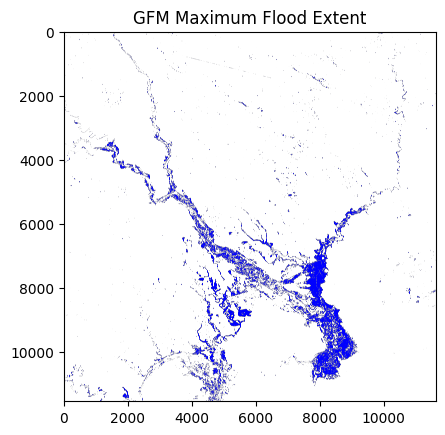

In [8]:
cmap = ListedColormap(['none', 'blue'])

plt.figure()
plt.imshow(binary_result, cmap=cmap)
plt.title("GFM Maximum Flood Extent")
plt.show()